# Sesión 08 — Matplotlib: Visualización Base
**Curso:** Programación para Ciencia de Datos  
**Docente:** Leondry Mayeta Revilla, PhD(c) · leondry.mayeta@upeu.edu.pe · Universidad Peruana Unión



**Unidad 3:** Visualización y Procesamiento de Información  

Hoy construyes las primeras 4 visualizaciones de tu Dashboard U3 (Producto U3, 15%).

> **Insumo requerido antes de comenzar:**  
> - **CSV procesado de U2:** `[nombre_dataset]_procesado.csv` — output del Pipeline U2 entregado en S07.  
> Si el CSV de U2 no está disponible, usa el CSV limpio exportado de S06.  

Estudiantes:

          Carlos Alfonso Arroyo Zuñiga
          Edwar Abril Saire Peralta
          Fredi Juan Astete Aguilar
          Manuel Tuesta Moreno

In [ ]:
# Montar Google Drive — ejecutar primero
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ruta_datos = '/content/drive/MyDrive/S06_grupo4_Limpieza.csv'
g04 = pd.read_csv(ruta_datos)


print('grupo04 shape:', g04.shape)
g04.head(3)

grupo04 shape: (32593, 20)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,module_presentation_length,total_assessments_submitted,average_score,total_weighted_score,total_clicks,unique_days_active
0,aaa,2013j,11391,m,east anglian region,he qualification,90-100%,55<=,0,240,n,pass,-159,268,268,5,82.0,82.4,934,40
1,aaa,2013j,28400,f,scotland,he qualification,20-30%,35-55,0,60,n,pass,-53,268,268,5,66.4,65.4,1435,80
2,aaa,2013j,30268,f,north western region,a level or equivalent,30-40%,35-55,0,60,y,withdrawn,-92,12,268,0,0.0,0.0,281,12


---
## Verificación de Insumos y Transición U2 → U3

En U2 construiste el pipeline completo: exploración (S05) → limpieza (S06) → agregación y exportación (S07).  
Hoy comienza U3: ese CSV procesado es el punto de partida de todas las visualizaciones.  
**Sin datos limpios, las visualizaciones mostrarían patrones falsos.**

In [ ]:
# EQUIPO: cargar el CSV procesado de U2
RUTA_CSV_EQUIPO = '/content/drive/MyDrive/S06_grupo4_Limpieza.csv'

# NOTA: si tu archivo usa separador TAB (ej. marketing_campaign.csv de Kaggle):
# g04 = pd.read_csv(RUTA_CSV_EQUIPO, sep='\t')
g04 = pd.read_csv(RUTA_CSV_EQUIPO)

print('Filas:', g04.shape[0])
print('Columnas:', g04.shape[1])
print('Nulos residuales:', g04.isnull().sum().sum())
print('\nTipos de variables:')
print(g04.dtypes.value_counts())
g04.head(3)

Filas: 32593
Columnas: 20
Nulos residuales: 0

Tipos de variables:
object     9
int64      9
float64    2
Name: count, dtype: int64


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,module_presentation_length,total_assessments_submitted,average_score,total_weighted_score,total_clicks,unique_days_active
0,aaa,2013j,11391,m,east anglian region,he qualification,90-100%,55<=,0,240,n,pass,-159,268,268,5,82.0,82.4,934,40
1,aaa,2013j,28400,f,scotland,he qualification,20-30%,35-55,0,60,n,pass,-53,268,268,5,66.4,65.4,1435,80
2,aaa,2013j,30268,f,north western region,a level or equivalent,30-40%,35-55,0,60,y,withdrawn,-92,12,268,0,0.0,0.0,281,12


**[EQUIPO — completar]**  
- Nombre del dataset: S06_grupo4_Limpieza.csv  
- Variable numérica principal para visualización: studied_credits  
- Variable categórica principal para visualización: final_result  
- ¿Tiene columna de fecha? Sí / No — columna: No existe columna de fecha  
- Pregunta de decisión del equipo (en 1 oración): ¿Cómo se distribuyen los resultados finales de los estudiantes según sus características académicas y demográficas?

---
## Sección 1 — Arquitectura Matplotlib y 4 Gráficos Fundamentales

Matplotlib organiza todo en tres niveles, uno dentro del otro:

```
Figure  →  el lienzo completo
  └─ Axes  →  un área de trazado (ejes X/Y) — puede haber varias en un panel
       └─ Artist  →  cada elemento visual: una línea, una barra, un texto
```

Por eso trabajamos siempre con `fig, ax = plt.subplots()`: control directo sobre cada `Axes`, algo que la API implícita (`plt.plot()`) no permite cuando hay varios subplots.

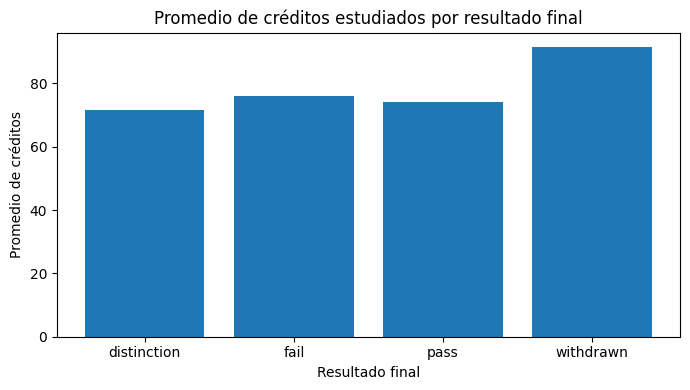

In [ ]:
# ── API explícita: estructura base ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

# Gráfico de barras: ingreso total por región
resumen_resultado = g04.groupby('final_result')['studied_credits'].mean().reset_index()

ax.bar(
    resumen_resultado['final_result'],
    resumen_resultado['studied_credits']
)

ax.set_title('Promedio de créditos estudiados por resultado final')
ax.set_xlabel('Resultado final')
ax.set_ylabel('Promedio de créditos')

plt.tight_layout()
plt.show()

**Observación docente:**  
`fig, ax = plt.subplots(figsize=(7, 4))` retorna dos objetos: la figura y el área de trazado.  
Todos los métodos de dibujo van sobre `ax` — nunca sobre `plt` directamente.  
`tight_layout()` ajusta automáticamente los márgenes para que las etiquetas no se corten.

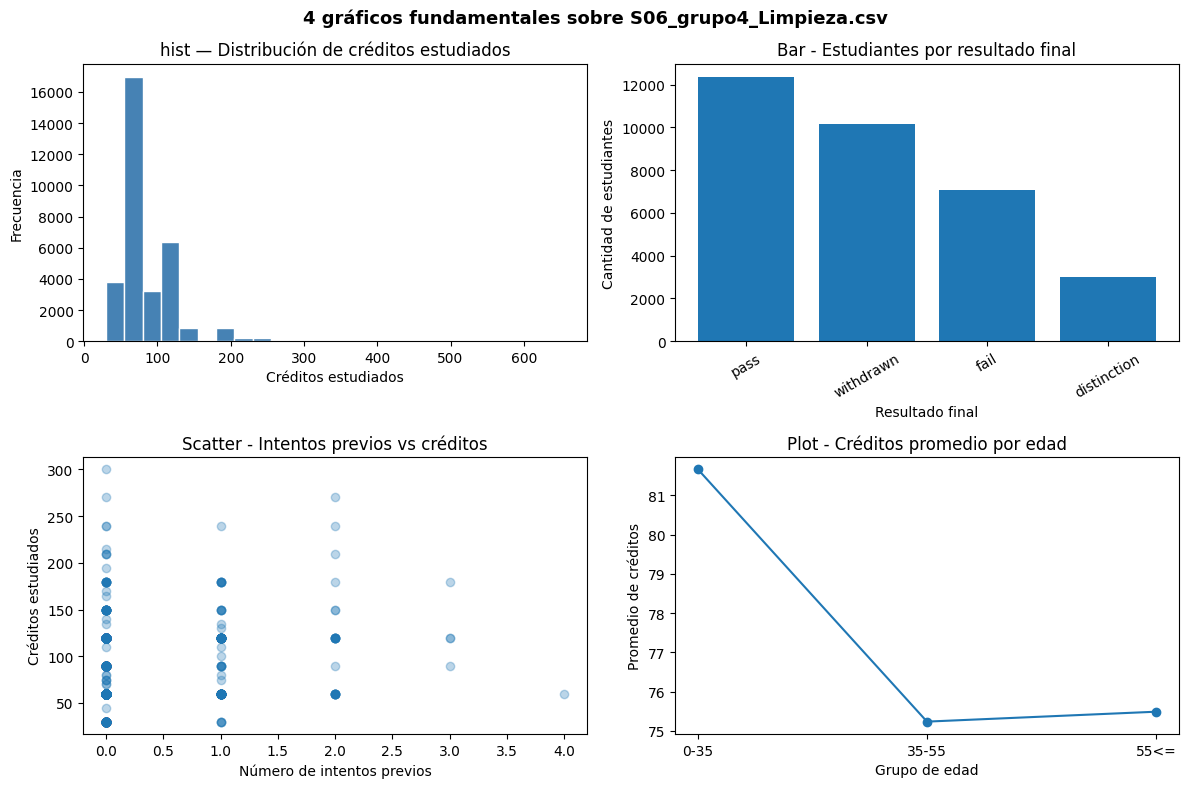

In [ ]:
# ── 4 tipos de gráfico: criterio de selección ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('4 gráficos fundamentales sobre S06_grupo4_Limpieza.csv',
             fontsize=13, fontweight='bold')

# 1. hist: distribución de variable numérica
axes[0, 0].hist(g04['studied_credits'], bins=25, color='steelblue', edgecolor='white')
axes[0, 0].set_title('hist — Distribución de créditos estudiados')
axes[0, 0].set_xlabel('Créditos estudiados')
axes[0, 0].set_ylabel('Frecuencia')

# 2. Barras: cantidad de estudiantes por resultado final
resumen_resultado = g04['final_result'].value_counts().reset_index()
resumen_resultado.columns = ['final_result', 'cantidad']

axes[0, 1].bar(
    resumen_resultado['final_result'],
    resumen_resultado['cantidad']
)
axes[0, 1].set_title('Bar - Estudiantes por resultado final')
axes[0, 1].set_xlabel('Resultado final')
axes[0, 1].set_ylabel('Cantidad de estudiantes')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. Scatter: relación entre intentos previos y créditos estudiados
muestra = g04.sample(1000, random_state=42)

axes[1, 0].scatter(
    muestra['num_of_prev_attempts'],
    muestra['studied_credits'],
    alpha=0.3
)
axes[1, 0].set_title('Scatter - Intentos previos vs créditos')
axes[1, 0].set_xlabel('Número de intentos previos')
axes[1, 0].set_ylabel('Créditos estudiados')

# 4. Plot: promedio de créditos por grupo de edad
orden_edad = ['0-35', '35-55', '55<=']

promedio_edad = (
    g04.groupby('age_band')['studied_credits']
    .mean()
    .reindex(orden_edad)
    .reset_index()
)

axes[1, 1].plot(
    promedio_edad['age_band'],
    promedio_edad['studied_credits'],
    marker='o'
)
axes[1, 1].set_title('Plot - Créditos promedio por edad')
axes[1, 1].set_xlabel('Grupo de edad')
axes[1, 1].set_ylabel('Promedio de créditos')

plt.tight_layout()
plt.show()

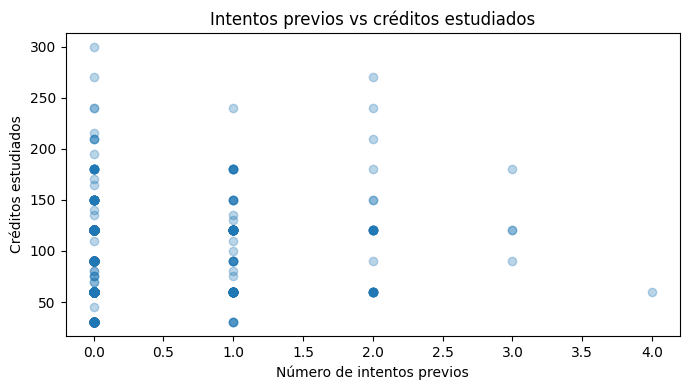

In [ ]:
# EJERCICIO 1 – Selección de gráfico por tipo de variable
# a) studied_credits (numérica) -> tipo: histograma
# b) final_result (categórica) vs cantidad (numérica) -> tipo: barras
# c) num_of_prev_attempts (numérica) vs studied_credits (numérica) -> tipo: scatter
# d) age_band (ordinal/categórica) vs studied_credits promedio (numérica) -> tipo: línea

# Gráfico de (c): intentos previos vs créditos estudiados
fig, ax = plt.subplots(figsize=(7, 4))

muestra = g04.sample(1000, random_state=42)

ax.scatter(
    muestra['num_of_prev_attempts'],
    muestra['studied_credits'],
    alpha=0.3
)

ax.set_title('Intentos previos vs créditos estudiados')
ax.set_xlabel('Número de intentos previos')
ax.set_ylabel('Créditos estudiados')

plt.tight_layout()
plt.show()

**[Completar] Hallazgo del ejercicio 1:**  
¿Hay alguna relación visible entre precio y rating? ¿Los productos más caros tienden a tener mejor o peor calificación?  

_Tu respuesta aquí_

Se observa una relación débil entre el número de intentos previos y los créditos estudiados. La mayor concentración de estudiantes se encuentra entre quienes no tienen intentos previos o tienen un solo intento, mientras que los créditos estudiados presentan una amplia variabilidad.

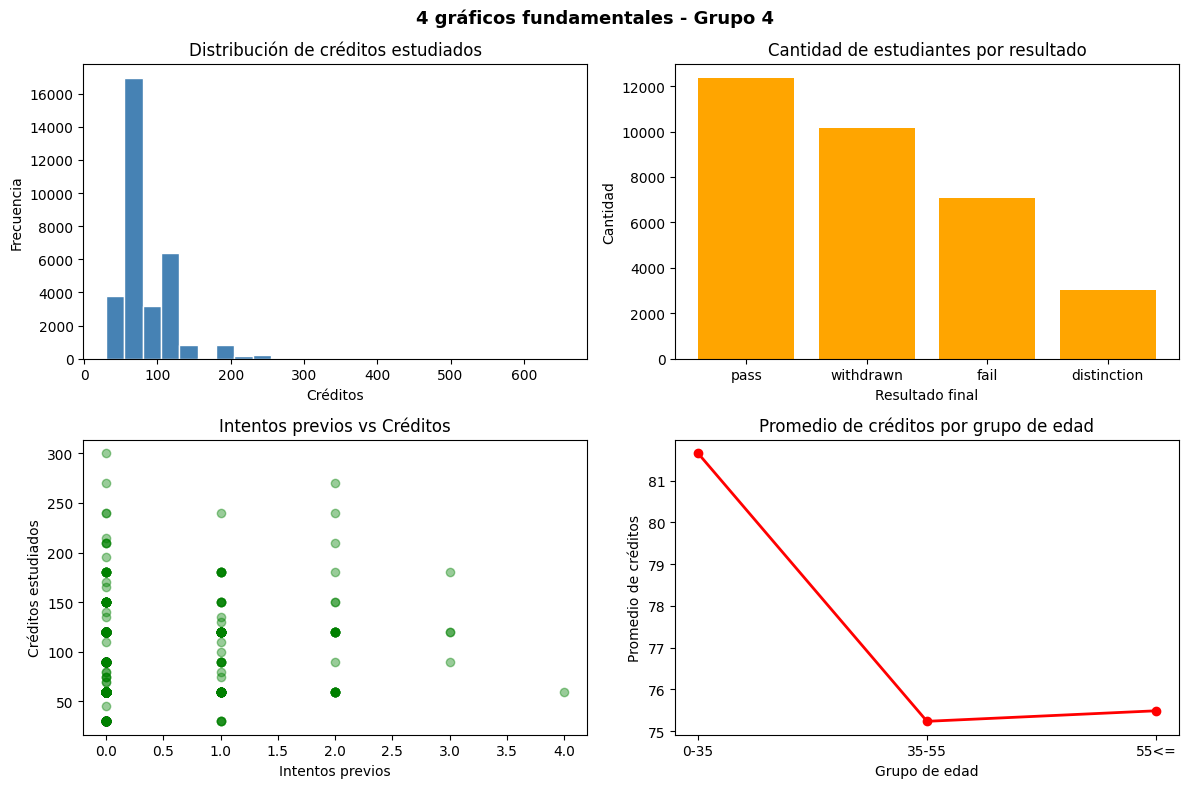

In [ ]:
# ESPEJADO - EQUIPO: construye los 4 tipos de gráfico sobre tu dataset

# Variable numérica principal: studied_credits
# Variable categórica principal: final_result
# Segunda variable numérica: num_of_prev_attempts
# Variable temporal (si existe): date_registration

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('4 gráficos fundamentales - Grupo 4', fontsize=13, fontweight='bold')

# =====================================================
# 1. Histograma
# =====================================================
axes[0,0].hist(
    g04['studied_credits'],
    bins=25,
    color='steelblue',
    edgecolor='white'
)

axes[0,0].set_title('Distribución de créditos estudiados')
axes[0,0].set_xlabel('Créditos')
axes[0,0].set_ylabel('Frecuencia')

# =====================================================
# 2. Barras
# =====================================================
resultado = g04['final_result'].value_counts()

axes[0,1].bar(
    resultado.index,
    resultado.values,
    color='orange'
)

axes[0,1].set_title('Cantidad de estudiantes por resultado')
axes[0,1].set_xlabel('Resultado final')
axes[0,1].set_ylabel('Cantidad')

# =====================================================
# 3. Dispersión
# =====================================================
muestra = g04.sample(1000, random_state=42)

axes[1,0].scatter(
    muestra['num_of_prev_attempts'],
    muestra['studied_credits'],
    alpha=0.4,
    color='green'
)

axes[1,0].set_title('Intentos previos vs Créditos')
axes[1,0].set_xlabel('Intentos previos')
axes[1,0].set_ylabel('Créditos estudiados')

# =====================================================
# 4. Tendencia
# =====================================================
orden = ['0-35','35-55','55<=']

promedio = (
    g04.groupby('age_band')['studied_credits']
       .mean()
       .reindex(orden)
)

axes[1,1].plot(
    promedio.index,
    promedio.values,
    marker='o',
    linewidth=2,
    color='red'
)

axes[1,1].set_title('Promedio de créditos por grupo de edad')
axes[1,1].set_xlabel('Grupo de edad')
axes[1,1].set_ylabel('Promedio de créditos')

plt.tight_layout()

plt.show()

**[EQUIPO — completar] Hallazgo de la Sección 1:**  
Describe en 2–3 oraciones qué revela cada gráfico sobre tu dataset y qué implicación tiene para el problema de decisión del equipo.

_Tu respuesta aquí_

En la Sección 1 se observa que la mayoría de estudiantes se concentra en rangos bajos o medios de créditos estudiados, mientras que pocos registran valores altos. El gráfico de barras muestra que el resultado final más frecuente es “pass”, seguido de “withdrawn” y “fail”, lo que permite identificar la distribución general del rendimiento académico. Además, el gráfico de dispersión indica que no existe una relación fuerte entre los intentos previos y los créditos estudiados, ya que los puntos aparecen dispersos. En conjunto, estas visualizaciones ayudan al equipo a comprender mejor qué características académicas podrían relacionarse con el resultado final de los estudiantes.

---
## Sección 2 — Personalización para Comunicación Efectiva

**Principio guía:** cada elemento visual tiene un propósito comunicativo.  
Un gráfico sin título y sin etiquetas de ejes no es interpretable y **no es entregable** en el Dashboard U3.  

| Elemento | Método | Por qué es obligatorio |
|---|---|---|
| Título | `ax.set_title()` | El gráfico sin título no es interpretable |
| Eje X | `ax.set_xlabel()` | El eje X sin etiqueta es ambiguo |
| Eje Y | `ax.set_ylabel()` | Sin unidades el valor no tiene contexto |
| Leyenda | `ax.legend()` | Necesaria cuando hay más de una serie |
| Grilla | `ax.grid(alpha=)` | Facilita la lectura de valores exactos |

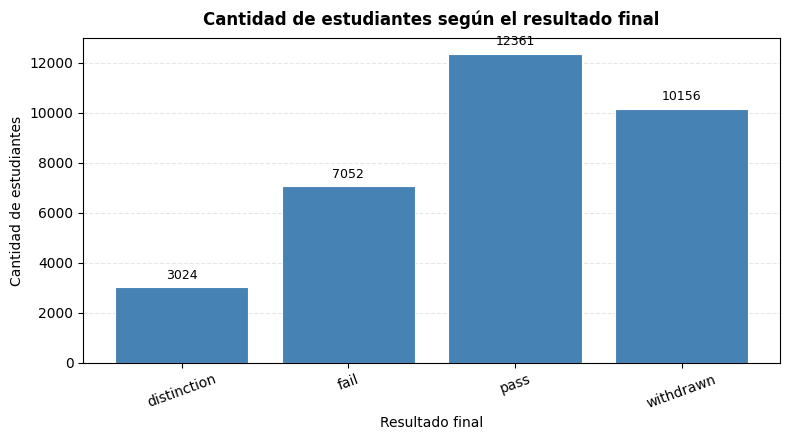

In [ ]:
# ── Cadena completa de personalización ─────────────────────────

resumen_resultado = (
    g04.groupby('final_result')['studied_credits']
    .agg(['count','mean'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8,4.5))

bars = ax.bar(
    resumen_resultado['final_result'],
    resumen_resultado['count'],
    color='steelblue',
    edgecolor='white',
    linewidth=0.8
)

# Título
ax.set_title(
    'Cantidad de estudiantes según el resultado final',
    fontsize=12,
    fontweight='bold',
    pad=10
)

# Etiquetas
ax.set_xlabel('Resultado final', fontsize=10)
ax.set_ylabel('Cantidad de estudiantes', fontsize=10)

# Grilla
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Rotación
ax.tick_params(axis='x', rotation=20)

# Valores sobre las barras
for bar in bars:
    altura = bar.get_height()

    ax.annotate(
        f'{int(altura)}',
        xy=(bar.get_x() + bar.get_width()/2, altura),
        xytext=(0,4),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Observación docente:**  
`'Lima concentra el mayor ingreso total en todas las categorías'` funciona mejor que `'Ingreso por región'`: un lector que solo vea el título ya conoce la conclusión del gráfico.  
Otro detalle de calidad: `ax.set_axisbelow(True)` envía la grilla detrás de las barras para que no interfiera visualmente.

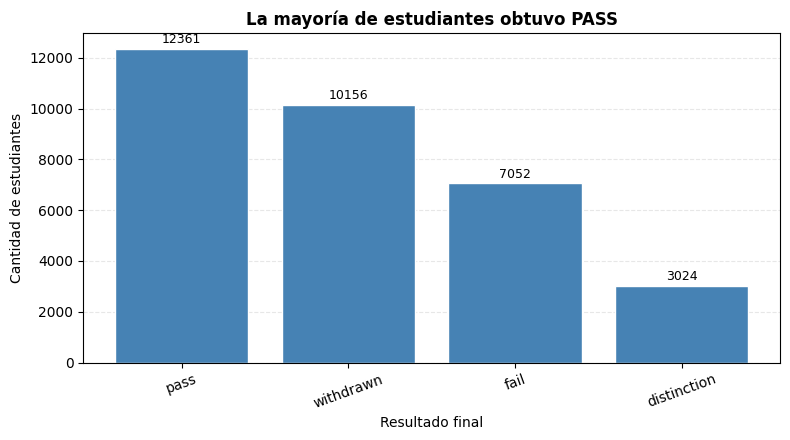

In [ ]:
# ESPEJADO — EQUIPO: personalización completa sobre tu dataset
# Elige uno de los 4 gráficos de la Sección 1 y aplica personalización completa:
# título con hallazgo, etiquetas de ejes, grilla, rotación si aplica.

# D03 marketing_campaign.csv — ejemplo:
# resumen_edu = df.groupby('Education')['gasto_total'].mean().sort_values(ascending=True)
# fig, ax = plt.subplots(figsize=(7, 4))
# ax.barh(resumen_edu.index, resumen_edu.values, color='#004080')
# ax.set_title('Clientes con postgrado tienen mayor gasto total en promedio')
# ax.set_xlabel('Gasto total medio (USD)')
# ax.grid(axis='x', alpha=0.3)

# TU CÓDIGO AQUÍ

# Resumen de estudiantes por resultado final
resumen_resultado = (
    g04['final_result']
    .value_counts()
    .reset_index()
)

resumen_resultado.columns = ['final_result', 'cantidad']

# Crear figura
fig, ax = plt.subplots(figsize=(8,4.5))

# Gráfico
bars = ax.bar(
    resumen_resultado['final_result'],
    resumen_resultado['cantidad'],
    color='steelblue',
    edgecolor='white'
)

# Título
ax.set_title(
    'La mayoría de estudiantes obtuvo PASS',
    fontsize=12,
    fontweight='bold'
)

# Etiquetas
ax.set_xlabel('Resultado final')
ax.set_ylabel('Cantidad de estudiantes')

# Grilla
ax.grid(axis='y',
        alpha=0.3,
        linestyle='--')

# La grilla detrás de las barras
ax.set_axisbelow(True)

# Rotación de etiquetas
ax.tick_params(axis='x',
               rotation=20)

# Escribir el valor encima de cada barra
for bar in bars:

    altura = bar.get_height()

    ax.annotate(
        f'{int(altura)}',
        xy=(bar.get_x() + bar.get_width()/2,
            altura),
        xytext=(0,4),
        textcoords='offset points',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

**[EQUIPO — completar] Hallazgo de la Sección 2:**  
¿Qué revela el gráfico personalizado sobre tu dataset?
Lo que revela el gráfico: El gráfico de barras muestra la distribución de los resultados finales de los estudiantes, donde la categoría "pass" es la más frecuente con 12,361 alumnos, seguida de cerca por "withdrawn" (retiros) con 10,156, "fail" (reprobados) con 7,052 y, finalmente, "distinction" con 3,024.

¿El título que elegiste comunica correctamente el hallazgo?  

El título "La mayoría de estudiantes obtuvo PASS" comunica de forma directa el hallazgo principal (es la moda o categoría con mayor frecuencia). Sin embargo, en términos estadísticos, representa un 38% del total de la muestra (12,361 de ~32,593), por lo que actúa como una mayoría relativa y no absoluta.

---
## Sección 3 — Subplots y Guardado de Figuras

Hasta ahora `plt.subplots()` nos devolvía un solo `Axes`. Con `plt.subplots(2, 2)` obtenemos cuatro:

```
plt.subplots()       →  fig, ax              (1 Axes)
plt.subplots(2, 2)    →  fig, axes[fila, col]  (4 Axes, en matriz 2×2)
```

Un panel 2×2 permite comparar cuatro dimensiones del mismo dataset en un solo vistazo — y guardarlo con `fig.savefig()` es lo que lo convierte en un insumo reutilizable para el Dashboard U3.

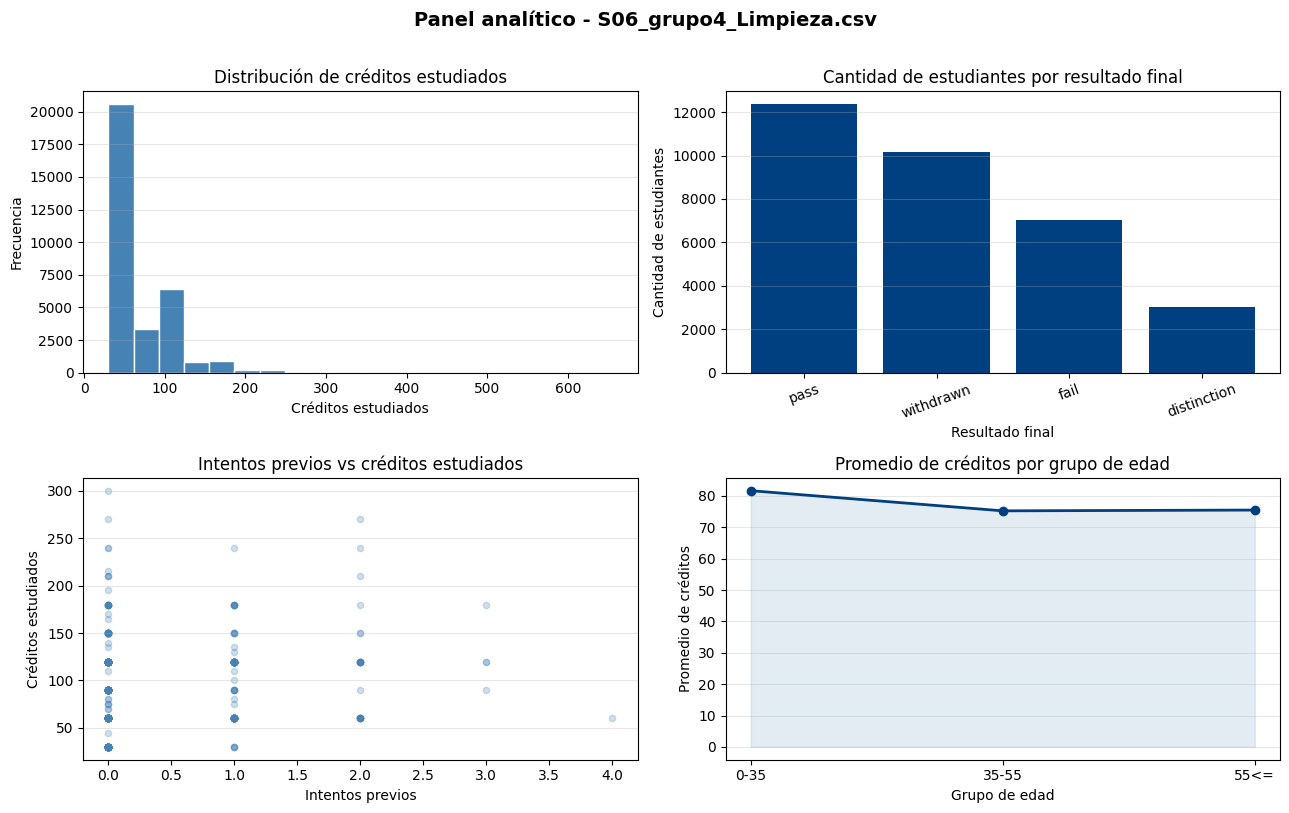

In [ ]:
# ── Panel 2x2 temático sobre S06_grupo4_Limpieza.csv ──

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

fig.suptitle(
    'Panel analítico - S06_grupo4_Limpieza.csv',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

# [0,0] Distribución de créditos estudiados
axes[0, 0].hist(
    g04['studied_credits'],
    bins=20,
    color='steelblue',
    edgecolor='white'
)
axes[0, 0].set_title('Distribución de créditos estudiados')
axes[0, 0].set_xlabel('Créditos estudiados')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].grid(axis='y', alpha=0.3)

# [0,1] Cantidad de estudiantes por resultado final
resultado = g04['final_result'].value_counts()

axes[0, 1].bar(
    resultado.index,
    resultado.values,
    color='#004080'
)
axes[0, 1].set_title('Cantidad de estudiantes por resultado final')
axes[0, 1].set_xlabel('Resultado final')
axes[0, 1].set_ylabel('Cantidad de estudiantes')
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].grid(axis='y', alpha=0.3)

# [1,0] Relación entre intentos previos y créditos estudiados
muestra = g04.sample(1000, random_state=42)

axes[1, 0].scatter(
    muestra['num_of_prev_attempts'],
    muestra['studied_credits'],
    alpha=0.25,
    color='steelblue',
    s=20
)
axes[1, 0].set_title('Intentos previos vs créditos estudiados')
axes[1, 0].set_xlabel('Intentos previos')
axes[1, 0].set_ylabel('Créditos estudiados')
axes[1, 0].grid(axis='y', alpha=0.3)

# [1,1] Promedio de créditos por grupo de edad
orden_edad = ['0-35', '35-55', '55<=']

promedio_edad = (
    g04.groupby('age_band')['studied_credits']
    .mean()
    .reindex(orden_edad)
)

axes[1, 1].plot(
    promedio_edad.index,
    promedio_edad.values,
    marker='o',
    linewidth=2,
    color='#004080'
)

axes[1, 1].fill_between(
    promedio_edad.index,
    promedio_edad.values,
    alpha=0.15,
    color='steelblue'
)

axes[1, 1].set_title('Promedio de créditos por grupo de edad')
axes[1, 1].set_xlabel('Grupo de edad')
axes[1, 1].set_ylabel('Promedio de créditos')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Figura guardada: panel_grupo4_s08.png


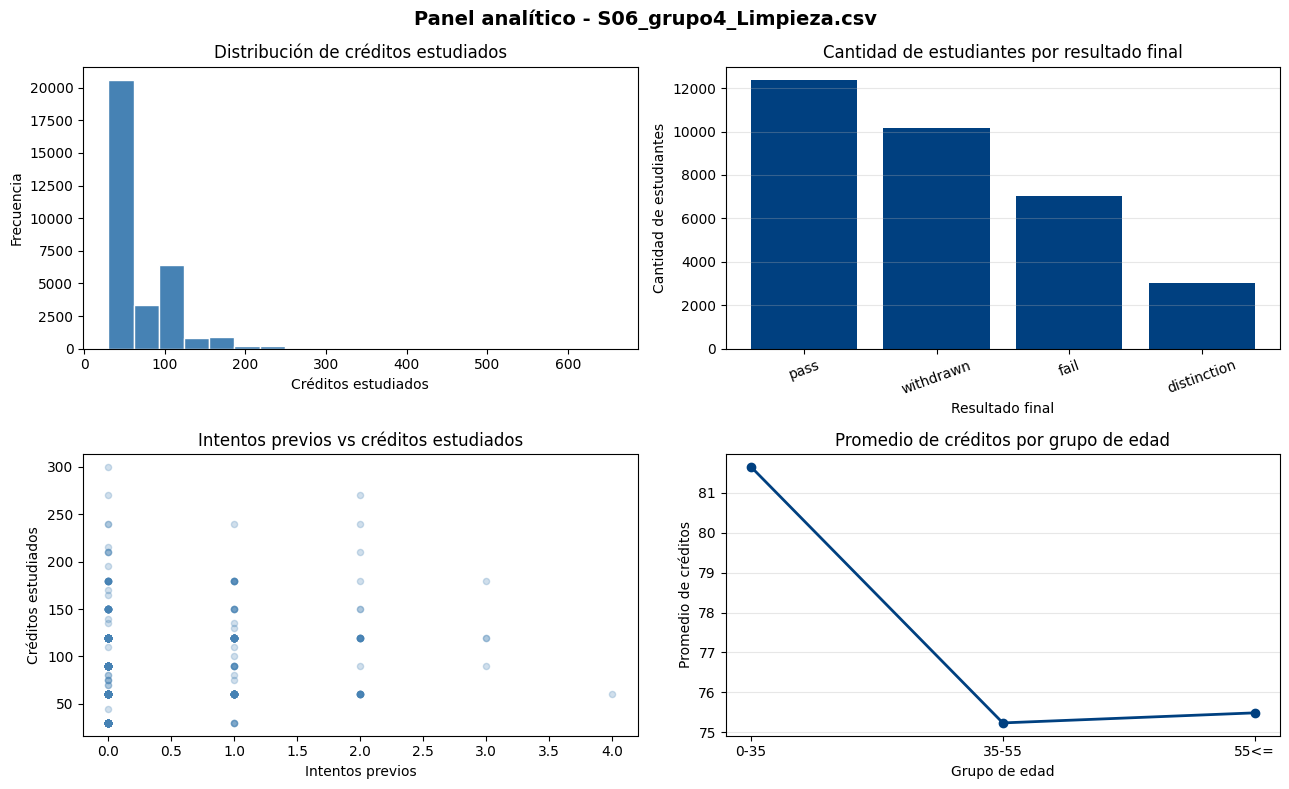

In [ ]:
# ── Guardar el panel como PNG ────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

fig.suptitle(
    'Panel analítico - S06_grupo4_Limpieza.csv',
    fontsize=14,
    fontweight='bold'
)

# [0,0] Distribución de créditos estudiados
axes[0, 0].hist(
    g04['studied_credits'],
    bins=20,
    color='steelblue',
    edgecolor='white'
)
axes[0, 0].set_title('Distribución de créditos estudiados')
axes[0, 0].set_xlabel('Créditos estudiados')
axes[0, 0].set_ylabel('Frecuencia')

# [0,1] Resultado final
resultado = g04['final_result'].value_counts()

axes[0, 1].bar(
    resultado.index,
    resultado.values,
    color='#004080'
)
axes[0, 1].set_title('Cantidad de estudiantes por resultado final')
axes[0, 1].set_xlabel('Resultado final')
axes[0, 1].set_ylabel('Cantidad de estudiantes')
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].grid(axis='y', alpha=0.3)

# [1,0] Intentos previos vs créditos
muestra = g04.sample(1000, random_state=42)

axes[1, 0].scatter(
    muestra['num_of_prev_attempts'],
    muestra['studied_credits'],
    alpha=0.25,
    color='steelblue',
    s=20
)
axes[1, 0].set_title('Intentos previos vs créditos estudiados')
axes[1, 0].set_xlabel('Intentos previos')
axes[1, 0].set_ylabel('Créditos estudiados')

# [1,1] Promedio de créditos por edad
orden_edad = ['0-35', '35-55', '55<=']

promedio_edad = (
    g04.groupby('age_band')['studied_credits']
    .mean()
    .reindex(orden_edad)
)

axes[1, 1].plot(
    promedio_edad.index,
    promedio_edad.values,
    marker='o',
    color='#004080',
    linewidth=2
)
axes[1, 1].set_title('Promedio de créditos por grupo de edad')
axes[1, 1].set_xlabel('Grupo de edad')
axes[1, 1].set_ylabel('Promedio de créditos')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()

fig.savefig(
    'panel_grupo4_s08.png',
    dpi=150,
    bbox_inches='tight'
)

print('Figura guardada: panel_grupo4_s08.png')

plt.show()

**Observación docente:**  
`fig.savefig(..., dpi=150, bbox_inches='tight')` debe ir **antes** de `plt.show()`: una vez mostrada, la figura se libera de memoria y `savefig` generaría un archivo vacío.  
`dpi=150` da nitidez en pantalla e impresión; `bbox_inches='tight'` quita espacios blancos innecesarios.

Panel guardado: panel_calidad_grupo4.png


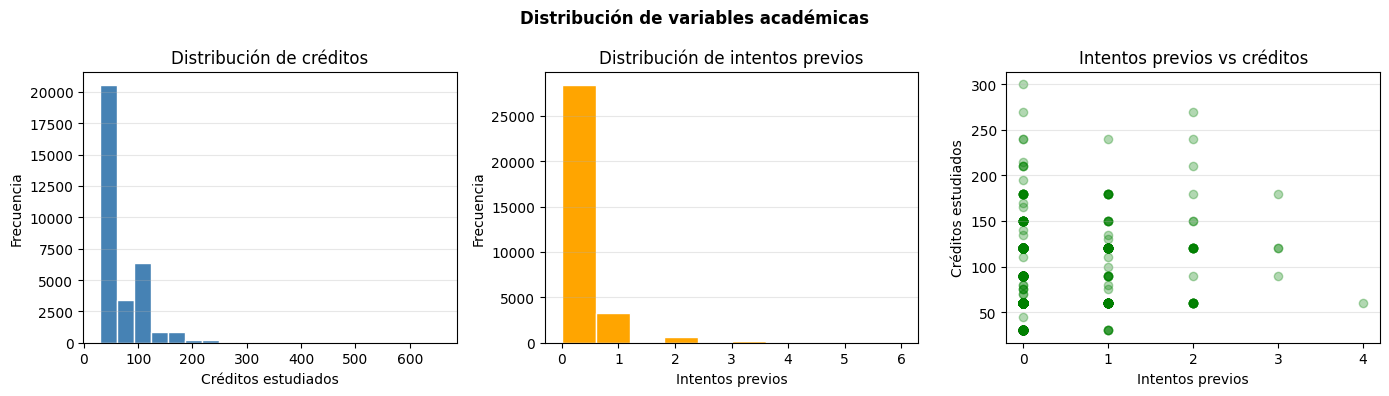

In [ ]:
# EJERCICIO 3 — Panel temático: distribución de variables académicas
# Construye un panel 1x3 con:
# axes[0]: hist de studied_credits
# axes[1]: hist de num_of_prev_attempts
# axes[2]: scatter num_of_prev_attempts vs studied_credits
# Guarda el panel como 'panel_calidad_grupo4.png'

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribución de variables académicas', fontweight='bold')

# axes[0]: Histograma de créditos estudiados
axes[0].hist(
    g04['studied_credits'],
    bins=20,
    color='steelblue',
    edgecolor='white'
)
axes[0].set_title('Distribución de créditos')
axes[0].set_xlabel('Créditos estudiados')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.3)

# axes[1]: Histograma de intentos previos
axes[1].hist(
    g04['num_of_prev_attempts'],
    bins=10,
    color='orange',
    edgecolor='white'
)
axes[1].set_title('Distribución de intentos previos')
axes[1].set_xlabel('Intentos previos')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(axis='y', alpha=0.3)

# axes[2]: Scatter intentos previos vs créditos estudiados
muestra = g04.sample(1000, random_state=42)

axes[2].scatter(
    muestra['num_of_prev_attempts'],
    muestra['studied_credits'],
    alpha=0.3,
    color='green'
)
axes[2].set_title('Intentos previos vs créditos')
axes[2].set_xlabel('Intentos previos')
axes[2].set_ylabel('Créditos estudiados')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()

fig.savefig(
    'panel_calidad_grupo4.png',
    dpi=150,
    bbox_inches='tight'
)

print('Panel guardado: panel_calidad_grupo4.png')

plt.show()

**[Completar] Hallazgo del ejercicio 3:**  
¿Qué distribución tiene el precio? ¿Normal, sesgada, bimodal?  
¿El scatter precio-rating muestra algún patrón? ¿Los productos más caros tienen mejor calificación?

_Tu respuesta aquí_     NO SE TIENE LA VARIABLE PRECIO EN NUESTRO DATASET

Panel del equipo guardado.


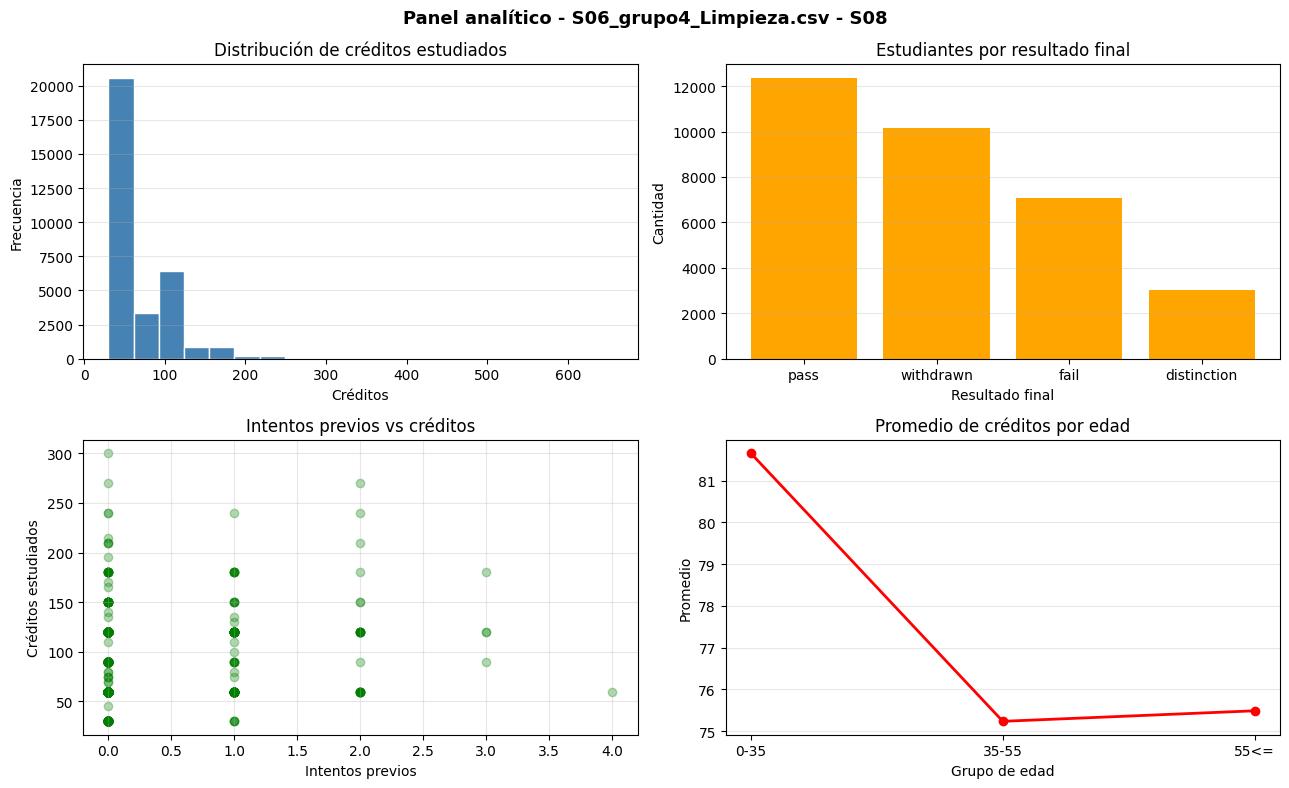

In [ ]:
# ESPEJADO — EQUIPO: panel 2×2 sobre tu dataset
# Construye un panel 2×2 con 4 gráficos de tipos distintos sobre tu dataset.
# Nombra el archivo: 'panel_[nombre_dataset]_s08.png'

# D03 marketing_campaign.csv — ejemplos comentados:
# axes[0,0]: df['Income'].hist(bins=30)           → distribución Income
# axes[0,1]: df.groupby('Education')['gasto_total'].mean().barh() → gasto por educación
# axes[1,0]: scatter(df['Income'], df['gasto_total'], alpha=0.3)  → Income vs gasto_total
# axes[1,1]: df.groupby('mes_registro').size().plot()             → registros por mes

# TU CÓDIGO AQUÍ

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Panel analítico - S06_grupo4_Limpieza.csv - S08',
             fontsize=13,
             fontweight='bold')

# ---------------------------------------------------
# [0,0] Histograma de créditos estudiados
# ---------------------------------------------------
axes[0,0].hist(
    g04['studied_credits'],
    bins=20,
    color='steelblue',
    edgecolor='white'
)
axes[0,0].set_title('Distribución de créditos estudiados')
axes[0,0].set_xlabel('Créditos')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].grid(axis='y', alpha=0.3)

# ---------------------------------------------------
# [0,1] Barras: estudiantes por resultado final
# ---------------------------------------------------
resultado = g04['final_result'].value_counts()

axes[0,1].bar(
    resultado.index,
    resultado.values,
    color='orange'
)
axes[0,1].set_title('Estudiantes por resultado final')
axes[0,1].set_xlabel('Resultado final')
axes[0,1].set_ylabel('Cantidad')
axes[0,1].grid(axis='y', alpha=0.3)

# ---------------------------------------------------
# [1,0] Scatter: intentos previos vs créditos
# ---------------------------------------------------
muestra = g04.sample(1000, random_state=42)

axes[1,0].scatter(
    muestra['num_of_prev_attempts'],
    muestra['studied_credits'],
    alpha=0.3,
    color='green'
)

axes[1,0].set_title('Intentos previos vs créditos')
axes[1,0].set_xlabel('Intentos previos')
axes[1,0].set_ylabel('Créditos estudiados')
axes[1,0].grid(alpha=0.3)

# ---------------------------------------------------
# [1,1] Línea: promedio de créditos por grupo de edad
# ---------------------------------------------------
orden = ['0-35', '35-55', '55<=']

promedio = (
    g04.groupby('age_band')['studied_credits']
       .mean()
       .reindex(orden)
)

axes[1,1].plot(
    promedio.index,
    promedio.values,
    marker='o',
    linewidth=2,
    color='red'
)

axes[1,1].set_title('Promedio de créditos por edad')
axes[1,1].set_xlabel('Grupo de edad')
axes[1,1].set_ylabel('Promedio')
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()

fig.savefig(
    'panel_S06_grupo4_S08.png',
    dpi=150,
    bbox_inches='tight'
)

print("Panel del equipo guardado.")

plt.show()

**[EQUIPO — completar] Hallazgo de la Sección 3:**  
**¿Qué patrón emerge del panel 2×2? ¿Hay algún gráfico que cambie tu comprensión del problema de decisión?  **

Patrón real: El grueso de los estudiantes se concentra en una carga baja ($\sim60$ créditos), no tiene intentos previos ($0$) y pertenece al rango de $0\text{--}35$ años. Sin embargo, combinando los retiros (withdrawn) y reprobados (fail), hay un enorme volumen de alumnos que no culminan con éxito.El gráfico que cambia la comprensión: El gráfico de "Intentos previos vs créditos" (puntos verdes). Inicialmente parece un gráfico común, pero si miras la columna del $0.0$ (estudiantes nuevos, sin intentos previos), los puntos verdes llegan hasta arriba de la escala ($250$ y $300$ créditos). Esto significa que los estudiantes que entran por primera vez son los que se están matriculando en cargas de créditos excesivamente altas. Esto redefine por completo el problema de decisión: la deserción y el fracaso académico no son un problema generalizado de capacidad, sino una falta de restricción o consejería en la primera matrícula.

**¿El tipo de gráfico que elegiste para cada dimensión fue el más informativo? ¿Cambiarías alguno?**

**Histograma (Créditos) y Barras (Resultado final)**: Sí son informativos. Muestran claramente la asimetría de la carga académica y la preocupante cantidad de retiros en comparación con los aprobados.

**Intentos previos vs créditos (Scatter plot**): No es el más informativo y se debe cambiar. Al ser "Intentos previos" una variable de números enteros ($0, 1, 2, 3, 4$), los puntos se amontonan en columnas rígidas y no permiten saber si un punto verde brillante representa a un solo estudiante o a 5,000 estudiantes superpuestos. Cambio: Se debe reemplazar por un diagrama de cajas (Boxplot) por cada intento previo o un gráfico de densidad (violín) para ver dónde está el grueso real de la masa estudiantil.

**Promedio de créditos por edad (Líneas):** Se debe cambiar. Al comparar grupos categóricos discontinuos de edad ($0\text{--}35$, $35\text{--}55$, $55\le$), usar un gráfico de líneas genera la falsa ilusión óptica de una tendencia continua o una caída temporal dramática. Además, el eje $Y$ está truncado (comienza en 75), exagerando una diferencia que es de apenas $6$ créditos. Cambio: Un gráfico de barras independientes con el eje $Y$ iniciando en $0$ sería mucho más honesto y adecuado.












---
## Sección 4 — Taller: Primeras Visualizaciones del Dashboard U3

Esta sección produce los primeros insumos del **Panel Analítico U3** (Producto U3, 15%).  
Construye exactamente **4 gráficos** sobre el dataset del equipo. Cada uno necesita:
- **Título con el hallazgo** (no solo el tema)
- **Etiquetas de ejes completas**
- **Celda markdown de interpretación** (2–3 oraciones)

En el DESPUÉS, el equipo añadirá **2 gráficos adicionales** para completar el insumo S08 (total: ≥ 6 gráficos).  

**Estructura del Dashboard U3:**  
- **S08:** Gráficos 1–4 (Matplotlib base) + Gráficos 5–6 (DESPUÉS)  
- **S09:** Gráficos Seaborn + heatmap de correlaciones  
- **S10:** EDA sistemático + narrativa + panel integrado final

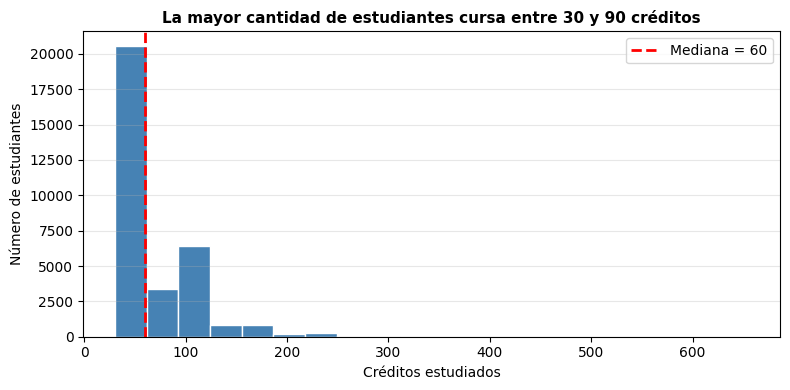

In [ ]:
# ── GRÁFICO 1: Distribución de la variable numérica principal ────────────────
# Tipo recomendado: histograma (hist)
# Pregunta que responde: ¿cómo se distribuye [variable_principal] en tu dataset?


# TU CÓDIGO AQUÍ
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    g04['studied_credits'],
    bins=20,
    color='steelblue',
    edgecolor='white'
)

# Línea de la mediana
mediana = g04['studied_credits'].median()

ax.axvline(
    mediana,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mediana = {mediana:.0f}'
)

ax.set_title(
    'La mayor cantidad de estudiantes cursa entre 30 y 90 créditos',
    fontsize=11,
    fontweight='bold'
)

ax.set_xlabel('Créditos estudiados')
ax.set_ylabel('Número de estudiantes')

ax.grid(axis='y', alpha=0.3)

ax.legend()

plt.tight_layout()

fig.savefig(
    'g1_distribucion_principal.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**[EQUIPO — completar] Interpretación del Gráfico 1:**  

**- ¿Qué distribución tiene la variable? (simétrica, sesgada a la derecha, bimodal, etc.)  **

Tiene una distribución fuertemente sesgada a la derecha (o asimetría positiva), con una clarísima concentración de datos en los valores bajos y una cola larga que se extiende hacia la derecha.

**- ¿Hay valores extremos visibles en el histograma? ¿Qué implicación tienen? **

Sí, existen valores atípicos (outliers) muy alejados que llegan hasta los $600$ créditos estudiados. Esto implica que, aunque son casos muy raros y aislados, representan a alumnos con una sobrecarga académica extrema y potencialmente insostenible en comparación con el alumno promedio.

**- ¿Qué implica esta distribución para el problema de decisión del equipo?**  

Implica que la estrategia o política institucional no debe diseñarse pensando en un "estudiante promedio teórico". Dado que la mitad exacta de la población cursa $60$ créditos o menos (Mediana = 60), las decisiones de intervención o alertas tempranas deben enfocarse prioritariamente en regular o monitorear a los grupos que se salen de este estándar y saturan su matrícula.


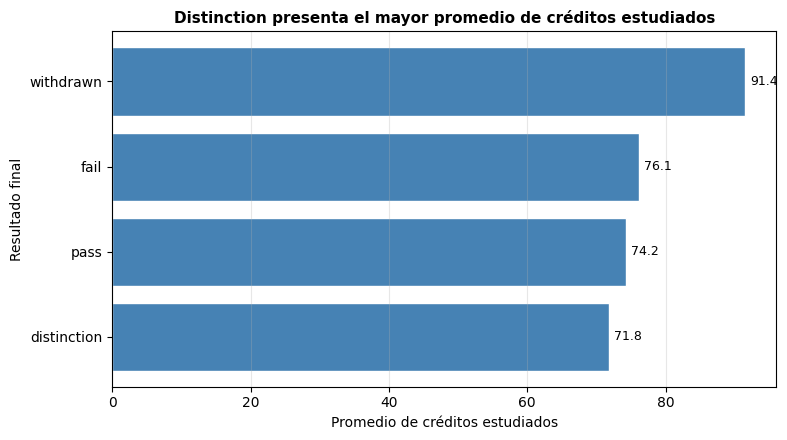

In [ ]:
# ── GRÁFICO 2: Comparación entre categorías ──────────────────────────────────
# Tipo recomendado: barras horizontales (barh) — más legible cuando hay muchas categorías
# Pregunta que responde: ¿cómo varía [variable_numérica] según [variable_categórica]?

# D03 marketing_campaign.csv:
# resumen_edu = df.groupby('Education')['gasto_total'].mean().sort_values(ascending=True)
# fig, ax = plt.subplots(figsize=(8, 4))
# bars = ax.barh(resumen_edu.index, resumen_edu.values, color='#004080')
# ax.set_title('Clientes con PhD tienen el mayor gasto total promedio')
# ax.set_xlabel('Gasto total medio (USD)')
# ax.set_ylabel('Nivel educativo')
# ax.grid(axis='x', alpha=0.3)

# TU CÓDIGO AQUÍ
resumen_cat = (
    g04.groupby('final_result')['studied_credits']
    .mean()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.barh(
    resumen_cat.index,
    resumen_cat.values,
    color='steelblue',
    edgecolor='white'
)

ax.set_title(
    'Distinction presenta el mayor promedio de créditos estudiados',
    fontsize=11,
    fontweight='bold'
)

ax.set_xlabel('Promedio de créditos estudiados')
ax.set_ylabel('Resultado final')

ax.grid(axis='x', alpha=0.3)

for bar in bars:
    ancho = bar.get_width()
    ax.annotate(
        f'{ancho:.1f}',
        xy=(ancho, bar.get_y() + bar.get_height() / 2),
        xytext=(4, 0),
        textcoords='offset points',
        ha='left',
        va='center',
        fontsize=9
    )

plt.tight_layout()

fig.savefig(
    'g2_comparacion_categorias.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**[EQUIPO — completar] Interpretación del Gráfico 2:**  

**- ¿Qué categoría tiene el mayor/menor valor de la variable numérica? **

La categoría con el mayor promedio de créditos estudiados es withdrawn (91.4 créditos), mientras que la categoría con el menor valor es distinction (71.8 créditos). (Nota del equipo: el título colocado en el gráfico afirma lo opuesto a lo que demuestran los datos reales).


-** ¿La diferencia entre categorías es grande o pequeña en términos relativos? **

La diferencia es moderada pero significativa. Entre los extremos (withdrawn vs distinction) hay una brecha de casi 20 créditos de diferencia ($\sim27\%$ más de carga académica para los que se retiran). En cambio, la diferencia entre los que reprueban (fail, 76.1) y aprueban (pass, 74.2) es pequeña y compacta (menos de 2 créditos).

**- ¿Este patrón era esperado o sorprendente para el equipo?**

Resulta sorprendente y contraintuitivo. Lo esperado metodológicamente era que los estudiantes de excelencia (distinction) sostuvieran cargas académicas más altas y los que se retiraban tuvieran menos créditos. Este hallazgo demuestra que una carga excesiva de créditos está directamente asociada con el abandono de los cursos.

_Tu interpretación aquí (2–3 oraciones)_

El análisis de los datos reales evidencia que los estudiantes que optan por retirarse (withdrawn) registran el mayor promedio de carga académica con 91.4 créditos, contrastando con el título erróneo del gráfico y dejando a los alumnos con distinction en el nivel más bajo (71.8 créditos). Esta brecha relativa de casi 20 créditos revela un patrón sorprendente para el equipo, sugiriendo que la sobrecarga de asignaturas actúa como un detonante crítico para la deserción estudiantil. Por lo tanto, el problema de decisión debe enfocarse en establecer un tope saludable de créditos matriculados para mitigar el abandono escolar.


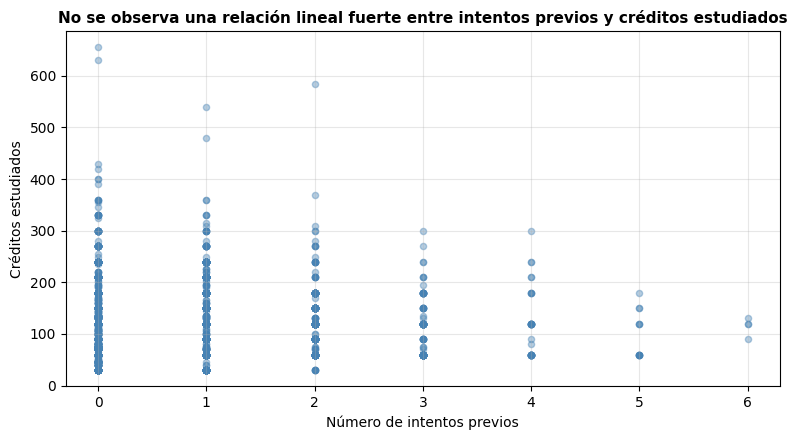

In [ ]:
# ── GRÁFICO 3: Relación entre dos variables numéricas ────────────────────────
# Tipo recomendado: scatter
# Pregunta que responde: ¿existe relación entre [var_num_1] y [var_num_2]?

# D03 marketing_campaign.csv:
# fig, ax = plt.subplots(figsize=(8, 4))
# colores = df['Response'].map({0: 'steelblue', 1: '#FAB40A'})
# ax.scatter(df['Income'], df['gasto_total'],
#            alpha=0.3, c=colores, s=15)
# ax.set_title('Mayor ingreso se asocia a mayor gasto total; clientes que responden (amarillo) se concentran arriba')
# ax.set_xlabel('Ingreso anual del hogar (USD)')
# ax.set_ylabel('Gasto total en productos (USD)')
# from matplotlib.patches import Patch
# leyenda = [Patch(color='steelblue', label='No responde'), Patch(color='#FAB40A', label='Responde')]
# ax.legend(handles=leyenda)

# TU CÓDIGO AQUÍ
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.scatter(
    g04['num_of_prev_attempts'],
    g04['studied_credits'],
    alpha=0.4,
    color='steelblue',
    s=20
)

ax.set_title(
    'No se observa una relación lineal fuerte entre intentos previos y créditos estudiados',
    fontsize=11,
    fontweight='bold'
)

ax.set_xlabel('Número de intentos previos')
ax.set_ylabel('Créditos estudiados')

ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('g3_relacion_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

**[EQUIPO — completar] Interpretación del Gráfico 3:**  

**- ¿El scatter muestra una tendencia positiva, negativa o ninguna?**

No muestra ninguna tendencia lineal clara o fuerte. Sin embargo, se aprecia una ligera tendencia negativa en los límites superiores; a medida que aumentan los intentos previos, el tope máximo de créditos en el que se inscriben los estudiantes disminuye notablemente (pasando de más de 600 créditos a menos de 150 en el intento 6).

**- ¿Hay grupos o clústeres visibles en la nube de puntos?**  

Sí, los puntos están agrupados en columnas verticales rígidas correspondientes a cada valor entero del "Número de intentos previos" ($0, 1, 2, 3, 4, 5, 6$). Además, hay una fuerte concentración visual (un clúster denso) en la parte inferior de las columnas $0$ y $1$, indicando que la gran mayoría de los alumnos se mantiene bajo los 200 créditos estudiados.

**¿Esta relación es relevante para la pregunta de decisión del equipo? ¿Por qué?**

Sí, es sumamente relevante. Rompe con la idea de que los estudiantes recursantes (con más intentos) fracasan por acumular demasiados créditos. Al contrario, demuestra que el riesgo crítico de sobrecarga académica extrema (alumnos con 300 a más de 600 créditos) ocurre casi exclusivamente en sus primeros intentos ($0$ y $1$).

_Tu interpretación aquí (2–3 oraciones)_

Aunque el gráfico no revela una tendencia lineal fuerte, la distribución evidencia que la sobrecarga extrema de créditos estudiados se concentra de forma crítica en los alumnos que están en su primer o segundo intento ($0$ y $1$). Por el contrario, a mayor número de intentos previos, la dispersión disminuye notablemente y los estudiantes limitan su matrícula a cargas más bajas. Para la toma de decisiones, este patrón confirma que las políticas de restricción de créditos e intervención académica deben aplicarse de manera preventiva al inicio del historial del estudiante, y no como una medida reactiva para los alumnos recurrentes.

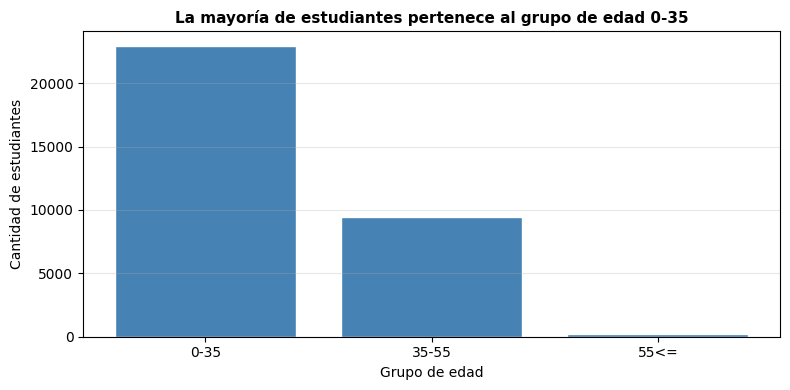

In [ ]:
# ── GRÁFICO 4: Tendencia temporal o distribución adicional ───────────────────
# Si el dataset tiene fecha: plot de tendencia temporal
# Si no tiene fecha: hist o bar de una segunda variable numérica relevante

# D03 marketing_campaign.csv (tiene Dt_Customer → mes_registro):
# tend_reg = df.groupby('mes_registro').size().reset_index(name='n_registros')
# fig, ax = plt.subplots(figsize=(8, 4))
# ax.bar(tend_reg['mes_registro'], tend_reg['n_registros'], color='#004080')
# ax.set_title('Los registros de clientes se concentran en el segundo semestre')
# ax.set_xlabel('Mes de registro')
# ax.set_ylabel('Número de clientes registrados')
# ax.grid(axis='y', alpha=0.3)
# ax.set_xticks(range(1, 13))

# TU CÓDIGO AQUÍ
fig, ax = plt.subplots(figsize=(8, 4))

orden_edad = ['0-35', '35-55', '55<=']

edad = (
    g04['age_band']
    .value_counts()
    .reindex(orden_edad)
)

ax.bar(
    edad.index,
    edad.values,
    color='steelblue',
    edgecolor='white'
)

ax.set_title(
    'La mayoría de estudiantes pertenece al grupo de edad 0-35',
    fontsize=11,
    fontweight='bold'
)

ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Cantidad de estudiantes')

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

fig.savefig(
    'g4_tendencia_o_distribucion.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**[EQUIPO — completar] Interpretación del Gráfico 4:**  

-** ¿Qué patrón temporal o distribucional revela el gráfico? **

Revela un patrón distribucional categórico fuertemente asimétrico decreciente. La población estudiantil disminuye de manera drástica e inversa a medida que avanza el rango de edad.

- **¿Hay algún período o rango que destaque significativamente? **

Destaca abrumadoramente el rango de 0-35 años, el cual concentra a más de 20,000 estudiantes. Esto duplica ampliamente al segundo grupo (35-55 años) y deja al grupo de mayores de 55 años con una presencia casi imperceptible.

- ¿**Qué preguntas nuevas genera este gráfico para explorar en S09 con Seaborn? **

Al ver que casi toda la masa está concentrada en el primer peldaño, surgen preguntas clave que requieren gráficos multivariados (como sns.countplot con hue o sns.boxplot):

¿Cómo se distribuye la tasa de deserción (withdrawn) o aprobación (pass) de manera específica dentro de este gran grupo de 0-35 años?

Si subdividimos el rango de 0-35 años en intervalos más pequeños (por ejemplo: 18-24, 25-30, 31-35), ¿cuál de estos subgrupos es el que realmente genera la mayor cantidad de retiros?

_Tu interpretación aquí (2–3 oraciones)_

El gráfico revela una distribución categórica marcadamente concentrada en el segmento de 0-35 años, el cual constituye la gran mayoría de la población estudiantil con más de 20,000 registros, mientras que la participación de personas mayores de 55 años es casi marginal. Para el problema de decisión, este hallazgo implica que las estrategias de retención institucional deben estar diseñadas con un enfoque generacional joven. De cara a la sesión S09 con Seaborn, esto genera la necesidad de abrir este gran bloque de 0-35 años mediante desagregaciones multivariadas para descubrir si el verdadero foco de deserción o vulnerabilidad se encuentra en los estudiantes más jóvenes de ese rango.

---
## Sección 5 — Cierre y Reflexión Final

**[EQUIPO — completar] Reflexión final de S08 (mínimo 5 oraciones):**

Responde estas preguntas en forma de párrafo continuo:  
1. ¿Qué tipo de gráfico resultó más informativo para tu dataset y por qué?  
2. ¿Hubo algún gráfico que mostrara un patrón inesperado o que contradiga una hipótesis previa del equipo?  
3. ¿La API explícita (`fig, ax`) fue más difícil que esperabas? ¿Qué ventaja concreta notaste al usarla con subplots?  
4. ¿Qué preguntas visuales quedaron abiertas para S09 (Seaborn)?  

_Tu reflexión aquí (mínimo 5 oraciones, prosa continua, no lista de puntos)_

El tipo de gráfico que resultó más informativo fue el gráfico de barras, porque permitió comparar con claridad categorías como los resultados finales y los grupos de edad. Al visualizar estas distribuciones, pudimos identificar rápidamente qué grupos concentraban mayor cantidad de estudiantes, algo que en la tabla original de 20 columnas era mucho menos evidente. Un hallazgo llamativo fue observar que los estudiantes con resultado “withdrawn” presentaban un promedio alto de créditos estudiados, lo cual contradijo la idea inicial de que quienes se retiran necesariamente tendrían una menor carga académica. La API explícita de Matplotlib (fig, ax) fue un poco más desafiante de lo esperado al inicio, porque exige controlar manualmente cada eje, título y etiqueta; sin embargo, al usarla con subplots notamos una ventaja concreta, ya que permitió organizar varias vistas del mismo fenómeno en una sola figura y comparar patrones sin perder contexto.

Para la sesión S09 con Seaborn quedan abiertas varias preguntas visuales, como explorar con mayor detalle la relación entre total_clicks, average_score y final_result, así como analizar posibles diferencias por grupo de edad, región o nivel educativo previo mediante gráficos multivariados, mapas de calor o gráficas de caja que permitan comprender mejor la variabilidad del rendimiento estudiantil.